In [ ]:
# Home Credit Default Risk - data loading and initial inspection
import pandas as pd
import numpy as np

# Load the data (adjust file path if needed)
df = pd.read_csv('../data/raw/application_train.csv')

# Basic info
print("Shape:", df.shape)
print("\nTarget distribution:\n", df['TARGET'].value_counts(normalize=True))

# Check data types
print("\nData types:\n", df.dtypes.value_counts())

# Missing values summary (top 10 columns by % missing)
missing_pct = df.isnull().mean() * 100
print("\nTop 10 columns by missing %:\n", missing_pct.sort_values(ascending=False).head(10))

# First rows to see structure
print("\nFirst 2 rows (first 5 columns):\n", df.iloc[:2, :5])

Shape: (307511, 122)

Target distribution:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Data types:
 float64    65
int64      41
str        16
Name: count, dtype: int64

Top 10 columns by missing %:
 COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64

First 2 rows (first 5 columns):
    SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR
0      100002       1         Cash loans           M            N
1      100003       0         Cash loans           F            N


In [5]:
# Full pipeline with ColumnTransformer and model training
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

# Assume X_train, X_test, y_train, y_test are already defined from previous steps
# Identify numeric and categorical columns (excluding target and ID)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
# Keep low-cardinality categoricals (e.g., <10 unique)
categorical_cols = [c for c in categorical_cols if X_train[c].nunique() < 10]

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Train and evaluate
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    print(f"{name}: ROC-AUC = {auc:.4f}")

print("\nBest model:", max(results, key=results.get))

/tmp/ipykernel_177555/1075913587.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
/home/muzzi/first_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.ht

Logistic Regression: ROC-AUC = 0.7428
Random Forest: ROC-AUC = 0.7113
XGBoost: ROC-AUC = 0.7466

Best model: XGBoost


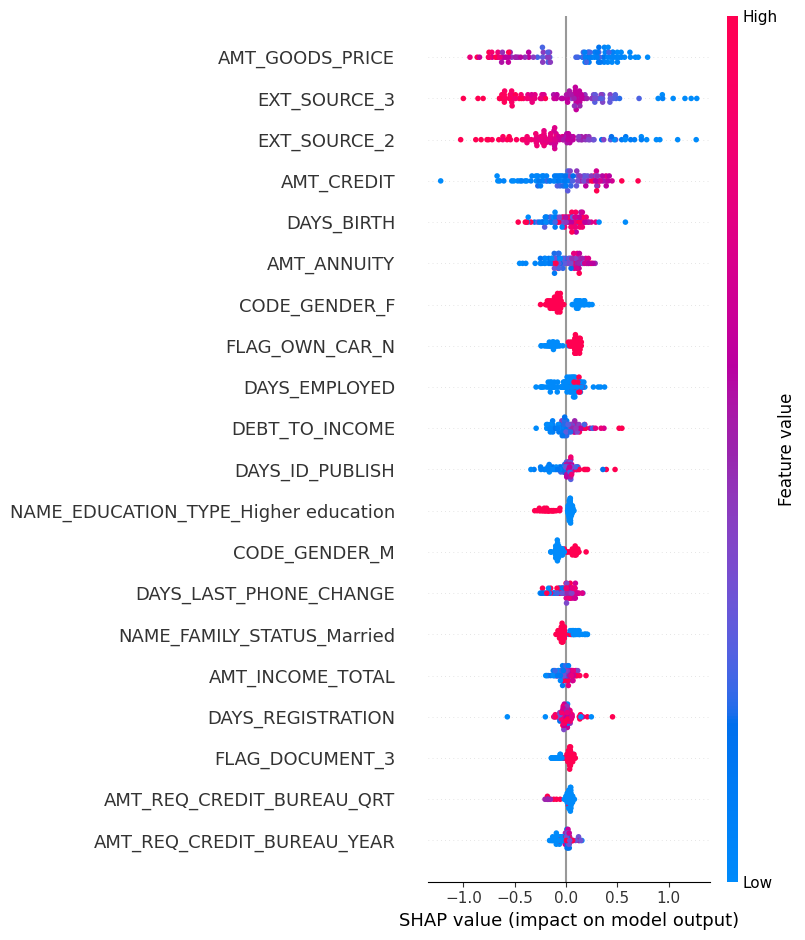

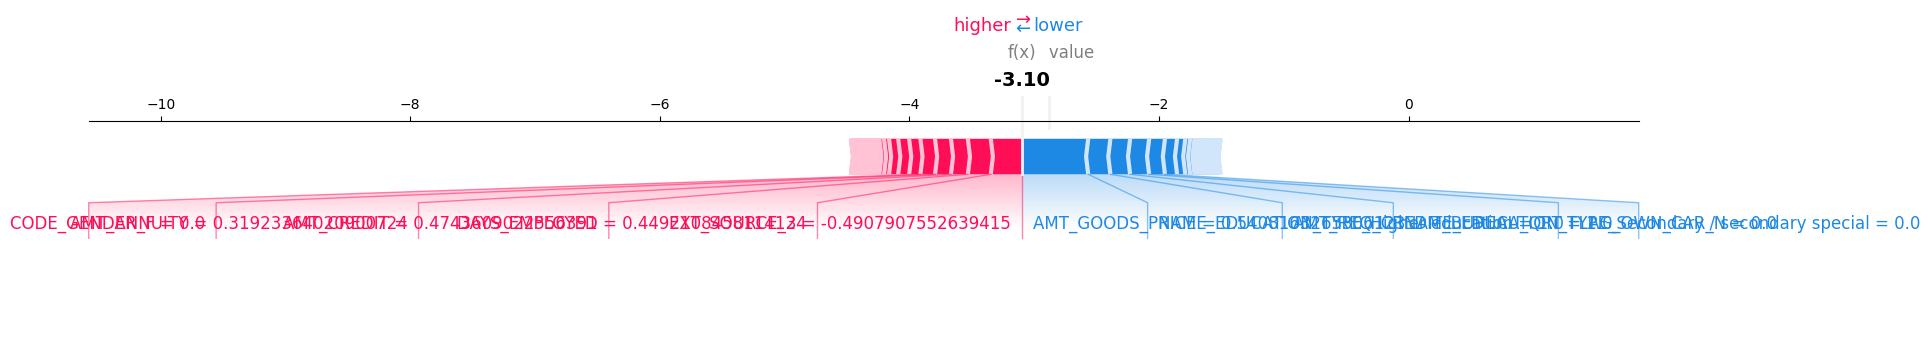

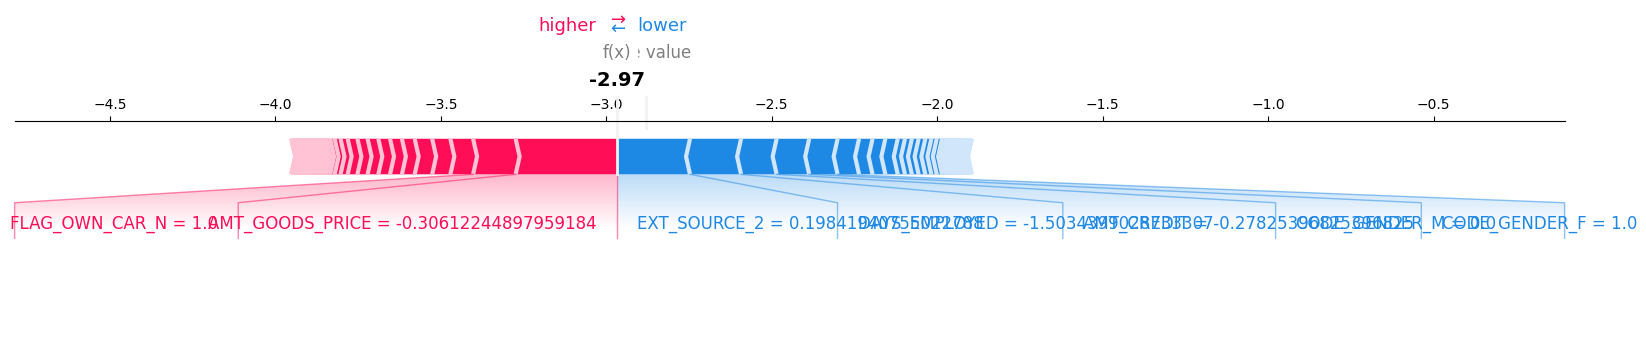

In [6]:
# SHAP analysis for XGBoost
import shap

# Train the best model (XGBoost) on the full preprocessed data
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])
final_pipeline.fit(X_train, y_train)

# Get the preprocessed training data for SHAP (the output of the preprocessor)
X_train_processed = final_pipeline.named_steps['preprocessor'].transform(X_train)
# Convert to dense array if sparse (one-hot encoding may produce sparse)
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()

# Get feature names after preprocessing
# For numeric columns, names are original; for categorical, OneHotEncoder generates names
feature_names = (numeric_cols + 
                 list(final_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_cols)))

# Create SHAP explainer using the model's predict_proba (for binary classification)
explainer = shap.Explainer(final_pipeline.named_steps['classifier'], X_train_processed, feature_names=feature_names)

# Compute SHAP values for a subset of test data (e.g., 100 rows to keep fast)
X_test_processed = final_pipeline.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()
shap_values = explainer(X_test_processed[:100])  # SHAP values for class 1 (default)

# Global summary plot
shap.summary_plot(shap_values, X_test_processed[:100], feature_names=feature_names)

# Local force plot for two individual predictions (e.g., first two test samples)
shap.initjs()
for i in range(2):
    shap.force_plot(explainer.expected_value, shap_values[i].values, X_test_processed[i], feature_names=feature_names, matplotlib=True)

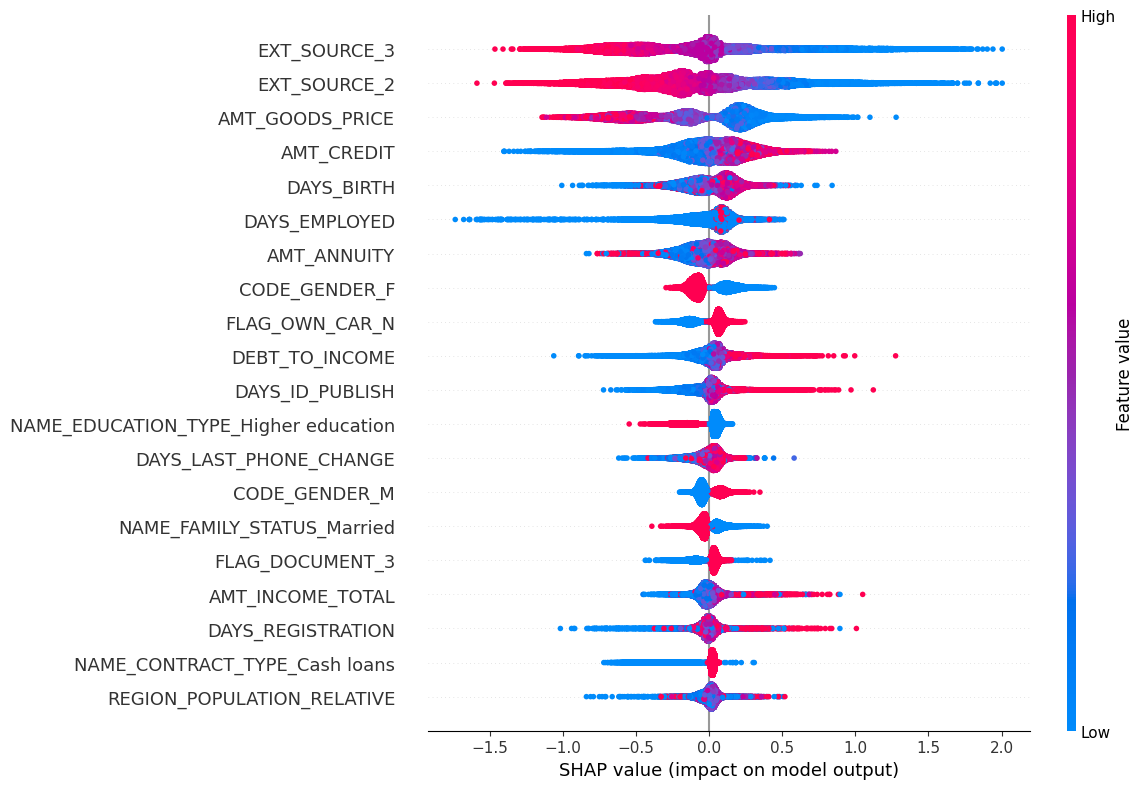

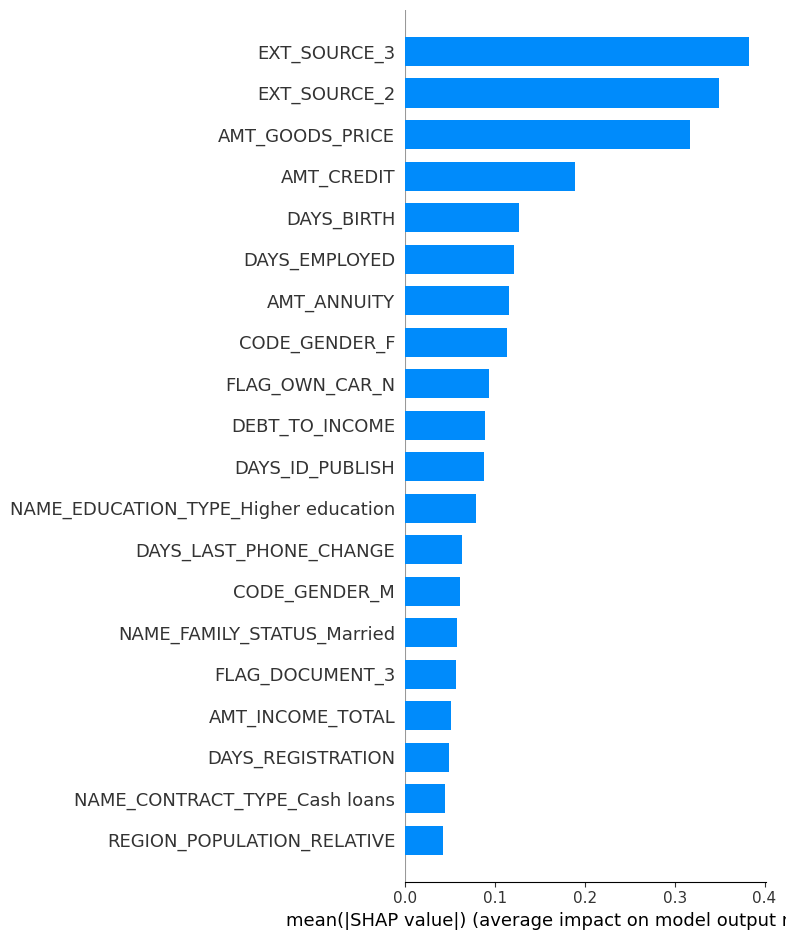

In [7]:
# ============================================================
# BETTER GLOBAL SHAP VISUALIZATION ⭐⭐⭐⭐⭐
# ============================================================

import shap
import matplotlib.pyplot as plt

# ============================================================
# EXTRACT TRAINED XGBOOST MODEL
# ============================================================

model = final_pipeline.named_steps[
    "classifier"
]

# ============================================================
# TREE EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(model)

# ============================================================
# SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(
    X_test_processed
)

# ============================================================
# GLOBAL BEESWARM PLOT ⭐⭐⭐⭐⭐
# BEST OVERALL GLOBAL VIEW
# ============================================================

plt.figure(figsize=(12,8))

shap.summary_plot(

    shap_values,

    X_test_processed,

    feature_names=feature_names,

    max_display=20,

    plot_size=(12,8)
)

# ============================================================
# BAR IMPORTANCE PLOT ⭐⭐⭐⭐⭐
# ============================================================

plt.figure(figsize=(10,8))

shap.summary_plot(

    shap_values,

    X_test_processed,

    feature_names=feature_names,

    plot_type="bar",

    max_display=20
)